In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("../01_data/processed/analysis_table.csv")

# Data profiling 

1️⃣ Overview
	•	количество событий
	•	пользователи
	•	операторы
	•	профили

⸻

2️⃣ Revenue
	•	распределение revenue
	•	revenue по времени

⸻

3️⃣ User behaviour
	•	события на пользователя
	•	revenue на пользователя

⸻

4️⃣ Segments
	•	оператор
	•	профиль
	•	приложение
	•	тип события
	•	статус пользователя

In [3]:
# строкова колонка time_utc перевод у datetime
df["time_utc"] = pd.to_datetime(df['time_utc'])

In [4]:
# відображеня лише 2 знаків після коми
pd.options.display.float_format = '{:.2f}'.format

In [5]:
df.head()

,id,time_utc,year_month,day_of_month,day_of_week,part_of_day,operator_key,profile_key,user_key,app_key,purchase_for,chat_or_media,user_status,credit_gross,revenue_free,revenue_paid,total_revenue
0,1,2022-05-19 01:53:00,2022-05-01,19,Thursday,night,2,28,3733,3,Chat per message,chat,paid,1.00,0.00,0.06,0.06
1,2,2022-05-19 01:54:00,2022-05-01,19,Thursday,night,2,28,3733,3,Chat per message,chat,paid,1.00,0.00,0.06,0.06
2,3,2022-05-19 01:57:00,2022-05-01,19,Thursday,night,2,28,3685,3,Chat per message,chat,paid,1.00,0.00,0.06,0.06
3,4,2022-05-19 01:57:00,2022-05-01,19,Thursday,night,2,28,3733,3,Chat per message,chat,paid,1.00,0.00,0.06,0.06
4,5,2022-05-19 02:18:00,2022-05-01,19,Thursday,night,2,28,3733,3,Chat per message,chat,paid,1.00,0.00,0.06,0.06


In [6]:
df.shape

(194970, 17)

In [7]:
df.describe()

,id,time_utc,day_of_month,operator_key,profile_key,user_key,app_key,credit_gross,revenue_free,revenue_paid,total_revenue
count,194970.00,194970,194970.00,194970.00,194970.00,194970.00,194970.00,194970.00,194970.00,194970.00,194970.00
mean,97485.50,2024-06-07 18:21:14.212032,16.53,2.39,9.62,725.32,2.75,4.20,0.01,0.24,0.25
min,1.00,2022-05-19 01:53:00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.06
25%,48743.25,2023-07-17 02:05:45,9.00,2.00,4.00,11.00,3.00,2.00,0.00,0.12,0.12
50%,97485.50,2024-07-04 15:06:00,17.00,2.00,7.00,41.00,3.00,2.00,0.00,0.12,0.12
75%,146227.75,2025-06-08 04:31:45,24.00,3.00,12.00,1062.00,3.00,2.00,0.00,0.12,0.12
max,194970.00,2026-02-01 01:13:00,31.00,5.00,30.00,3845.00,4.00,499.00,1.18,29.34,29.34
std,56283.14,NaN,8.83,0.68,6.84,1045.13,0.65,5.99,0.03,0.35,0.35


In [8]:
df.isna().sum()

id               0
time_utc         0
year_month       0
day_of_month     0
day_of_week      0
part_of_day      0
operator_key     0
profile_key      0
user_key         0
app_key          0
purchase_for     0
chat_or_media    0
user_status      0
credit_gross     0
revenue_free     0
revenue_paid     0
total_revenue    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

id                        int64
time_utc         datetime64[us]
year_month                  str
day_of_month              int64
day_of_week                 str
part_of_day                 str
operator_key              int64
profile_key               int64
user_key                  int64
app_key                   int64
purchase_for                str
chat_or_media               str
user_status                 str
credit_gross            float64
revenue_free            float64
revenue_paid            float64
total_revenue           float64
dtype: object

In [11]:
len(df)

194970

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 194970 entries, 0 to 194969
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   id             194970 non-null  int64         
 1   time_utc       194970 non-null  datetime64[us]
 2   year_month     194970 non-null  str           
 3   day_of_month   194970 non-null  int64         
 4   day_of_week    194970 non-null  str           
 5   part_of_day    194970 non-null  str           
 6   operator_key   194970 non-null  int64         
 7   profile_key    194970 non-null  int64         
 8   user_key       194970 non-null  int64         
 9   app_key        194970 non-null  int64         
 10  purchase_for   194970 non-null  str           
 11  chat_or_media  194970 non-null  str           
 12  user_status    194970 non-null  str           
 13  credit_gross   194970 non-null  float64       
 14  revenue_free   194970 non-null  float64       
 15  revenue_pai

In [13]:
#кол-во уник операторов
len(df["operator_key"].unique())

5

In [14]:
#кол-во уник users
df["user_key"].nunique()

3845

In [15]:
#кол-во уник profiles
df["profile_key"].nunique()

30

In [16]:
#кол-во уник apps
len(df["app_key"].unique())

4

In [17]:
df["purchase_for"].unique()

<StringArray>
[       'Chat per message',              'View Image',
            'Upload Photo',              'View Video',
            'Upload Video',         'Chat per minute',
           'Internal mail',            'Virtual Gift',
           'Contest Boost',            'Contest Vote',
                   'Gifts', 'View disappearing photo',
 'View disappearing video']
Length: 13, dtype: str

In [18]:
df["chat_or_media"].unique()

<StringArray>
['chat', 'media', 'other']
Length: 3, dtype: str

In [19]:
df["user_status"].unique()

<StringArray>
['paid', 'free', 'free+paid']
Length: 3, dtype: str

In [20]:
df["day_of_week"].unique()

<StringArray>
['Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday']
Length: 7, dtype: str

In [21]:
df['part_of_day'].unique()

<StringArray>
['night', 'afternoon', 'evening', 'morning']
Length: 4, dtype: str

In [22]:
df[['total_revenue', 'revenue_free', 'revenue_paid']].sum().round()

total_revenue   48189.00
revenue_free     1022.00
revenue_paid    47167.00
dtype: float64

In [23]:
df['revenue_free'].sum() + df['revenue_paid'].sum() == df['total_revenue'].sum()

np.True_

In [24]:
(df['total_revenue'] == 0).sum()

np.int64(0)

In [25]:
df[df['chat_or_media'] == 'chat']['total_revenue'].sum()

np.float64(16993.8272)

In [26]:
df[df['chat_or_media'] == 'media']['total_revenue'].sum()

np.float64(29881.726)

In [27]:
df[df['chat_or_media'] == 'other']['total_revenue'].sum()

np.float64(1313.8272000000002)

In [28]:
# колонка стоимость за 1 кредит
df['cost_per_credit'] = round(df["total_revenue"] / df["credit_gross"], 4)

In [29]:
wrong_cred_cost = df[df["cost_per_credit"] > 0.0588]

In [30]:
# рядки з аномальною вартістю credits
wrong_cred_cost

,id,time_utc,year_month,day_of_month,day_of_week,part_of_day,operator_key,profile_key,user_key,app_key,purchase_for,chat_or_media,user_status,credit_gross,revenue_free,revenue_paid,total_revenue,cost_per_credit
27047,27048,2023-02-10 03:02:00,2023-02-01,10,Friday,night,2,12,41,3,Chat per minute,chat,free+paid,2.00,0.00,0.24,0.24,0.12
27048,27049,2023-02-10 03:03:00,2023-02-01,10,Friday,night,2,12,41,3,Chat per minute,chat,free+paid,2.00,0.00,0.24,0.24,0.12
27049,27050,2023-02-10 03:07:00,2023-02-01,10,Friday,night,2,12,41,3,Chat per minute,chat,free+paid,2.00,0.00,0.24,0.24,0.12
27054,27055,2023-02-10 03:29:00,2023-02-01,10,Friday,night,3,17,2978,2,Chat per minute,chat,free,2.00,0.24,0.00,0.24,0.12
27056,27057,2023-02-10 03:37:00,2023-02-01,10,Friday,night,2,12,41,3,Chat per minute,chat,free+paid,2.00,0.00,0.24,0.24,0.12
27057,27058,2023-02-10 03:42:00,2023-02-01,10,Friday,night,2,12,41,3,Chat per minute,chat,free+paid,2.00,0.00,0.24,0.24,0.12
27058,27059,2023-02-10 03:47:00,2023-02-01,10,Friday,night,2,12,41,3,View Image,media,free+paid,10.00,0.00,1.40,1.40,0.14
27070,27071,2023-02-10 04:07:00,2023-02-01,10,Friday,night,2,12,41,3,Chat per minute,chat,free+paid,2.00,0.00,0.24,0.24,0.12
27071,27072,2023-02-10 04:08:00,2023-02-01,10,Friday,night,2,12,41,3,Chat per minute,chat,free+paid,2.00,0.00,0.24,0.24,0.12
27072,27073,2023-02-10 04:08:00,2023-02-01,10,Friday,night,3,1,2796,3,Chat per minute,chat,paid,2.00,0.00,0.24,0.24,0.12


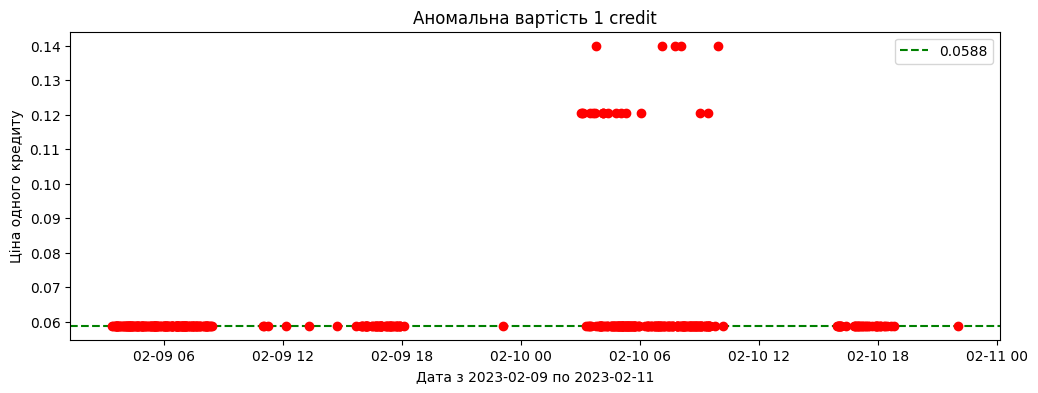

In [31]:
df_plot = df[df["time_utc"].between("2023-02-09", "2023-02-11")]
outliers = df_plot["cost_per_credit"] != 0.0588

fig, ax = plt.subplots(figsize=(12,4))

ax.axhline(0.0588, color="green", linestyle="--", label="0.0588")

ax.scatter(df_plot["time_utc"], 
           df_plot["cost_per_credit"],
           color="red", 
           label="аномалія", 
           zorder=3)

ax.set_xlabel("Дата з 2023-02-09 по 2023-02-11")
ax.set_ylabel("Ціна одного кредиту")
ax.set_title("Аномальна вартість 1 credit")
ax.legend(['0.0588'])

anomalies_plot = fig

Пропуски відсутні.  
Типи колонок відповідають очікуванням (time_utc приведена до datetime)  
**!!! Виявлено 21 рядок з невідповідністю cost_per_credit.**   
10-02-2023 приблизно з 03:00 до 10:00 для users з id (41, 2358, 2796, 2964, 2965, 2978) по-різному нараховувався revenue.  
За 1 credit могло нараховуватися 0.1204 або 0.14 замість стандартних 0.0588.  

**Overview**
<pre>
Тип                      Значення
---------------------------------
Кількість рядків:          194970  
Унікальних операторів:          5  
Унікальних профілів:           30  
Унікальних користувачів:     3845 
                 paid:        875
                 free:       2970
           *free+paid:         72
Кількість apps:                 4 
Суммарний дохід:           $48189
     free users:            $1022
     paid users:           $47167
    
Період даних:        з 2022-05-19 
                    по 2026-02-01
    </pre>
*free+paid - користувачі які були **free** та стали **paid**

revenue

In [32]:
df[df['revenue_free'] > 0]['revenue_free'].value_counts()

revenue_free
0.12    7255
0.06     370
0.59     237
0.29       6
0.24       3
1.18       3
0.35       2
0.24       2
0.47       1
Name: count, dtype: int64

In [33]:
df[df['revenue_paid'] > 0]['revenue_paid'].value_counts()

revenue_paid
0.12     126166
0.59      25182
0.06      21728
1.18      11818
0.29       1429
1.76        209
2.94        172
2.35        151
1.47         91
2.59         48
3.23         43
0.24         13
1.71         10
4.06          6
0.14          3
5.23          3
29.34         3
2.88          3
1.40          2
0.35          2
5.82          2
2.29          2
23.46         2
8.53          2
0.24          1
0.82          1
1.29          1
20.52         1
14.64         1
11.70         1
7.35          1
3.47          1
Name: count, dtype: int64

In [34]:
#транзакційні
df['total_revenue'].agg(['sum', 'mean', 'median', 'std', 'min', 'max'])

sum      48189.38
mean         0.25
median       0.12
std          0.35
min          0.06
max         29.34
Name: total_revenue, dtype: float64

In [35]:
##транзакційні paid
df[df['revenue_paid'] > 0]['revenue_paid'].agg(['sum', 'mean', 'median', 'std', 'min', 'max'])

sum      47167.42
mean         0.25
median       0.12
std          0.36
min          0.06
max         29.34
Name: revenue_paid, dtype: float64

In [36]:
df_paid = df[df['user_status'] != 'free']

In [37]:
df_free = df[df['user_status'] == 'free']

In [38]:
len(df_free) / len(df) * 100

3.8990613940606247

In [39]:
df_free['total_revenue'].sum() / df['total_revenue'].sum() * 100

np.float64(2.0436021211013533)

~4% транзакцій та ~2% доходу доводиться на **free** користувачів


In [40]:
df.head(1)

,id,time_utc,year_month,day_of_month,day_of_week,part_of_day,operator_key,profile_key,user_key,app_key,purchase_for,chat_or_media,user_status,credit_gross,revenue_free,revenue_paid,total_revenue,cost_per_credit
0,1,2022-05-19 01:53:00,2022-05-01,19,Thursday,night,2,28,3733,3,Chat per message,chat,paid,1.00,0.00,0.06,0.06,0.06


In [41]:
#місячні показники
df.groupby('year_month')['total_revenue'].sum().agg(['mean', 'median', 'std', 'min', 'max'])

mean     1047.60
median   1001.04
std       532.42
min         0.94
max      2729.85
Name: total_revenue, dtype: float64

In [42]:
#денні показники
df.groupby(df['time_utc'].dt.to_period("D"))['total_revenue'].sum().agg(['mean', 'median', 'std', 'min', 'max'])

mean      35.64
median    30.25
std       25.74
min        0.12
max      249.72
Name: total_revenue, dtype: float64

**Revenue**
<pre>
Тип                      Значення
---------------------------------
Сумарне revenue:           $48189
    Paid users:            $47167
                             ~98%
    Free users:             $1022
                              ~2%
Місячні показники:
    Середнє:             $1047.60  
    Медіана:             $1001.04  
    STD:                  $532.42
    Максимальне:         $2729.85
    
Денні показники:
    Середнє:               $35.64  
    Медіана:               $30.25  
    STD:                   $25.74
    Максимальне:          $249.72

Транзакційні показники:
    Середнє:                $0.25  
    Медіана:                $0.12  
    STD:                    $0.35
    Максимальне:           $29.34

    </pre>



# Revenue

In [43]:
#удаляю дані за лютий 2026 року
df = df[df["time_utc"] < "2026-02-01"]

In [44]:
df['year_month'] = df['year_month'].str[:-3]

In [45]:
#окремий ДФ ТІЛЬКИ з РЕВЕНЮ китами
#тобто РЕВЕНЮ НЕ КИТІВ буде 0
#для того щоб рахувати вплив китів на середні та инші показники

whales_id = [11, 41, 3, 597]

df_whales = df.copy()

# маска users НЕ китів
mask = ~df['user_key'].isin(whales_id)

df_whales.loc[mask, 'total_revenue'] = 0

In [46]:
#перевірка
df_whales['total_revenue'].agg(['sum', 'count'])

sum      30284.10
count   194966.00
Name: total_revenue, dtype: float64

In [47]:
#окремий ДФ БЕЗ китів взагалі
df_no_whales = df[~df['user_key'].isin(whales_id)]

In [48]:
#перевірка
df_no_whales['total_revenue'].agg(['sum', 'count'])

sum     17904.34
count   84258.00
Name: total_revenue, dtype: float64

In [49]:
df.head(2)

,id,time_utc,year_month,day_of_month,day_of_week,part_of_day,operator_key,profile_key,user_key,app_key,purchase_for,chat_or_media,user_status,credit_gross,revenue_free,revenue_paid,total_revenue,cost_per_credit
0,1,2022-05-19 01:53:00,2022-05,19,Thursday,night,2,28,3733,3,Chat per message,chat,paid,1.00,0.00,0.06,0.06,0.06
1,2,2022-05-19 01:54:00,2022-05,19,Thursday,night,2,28,3733,3,Chat per message,chat,paid,1.00,0.00,0.06,0.06,0.06


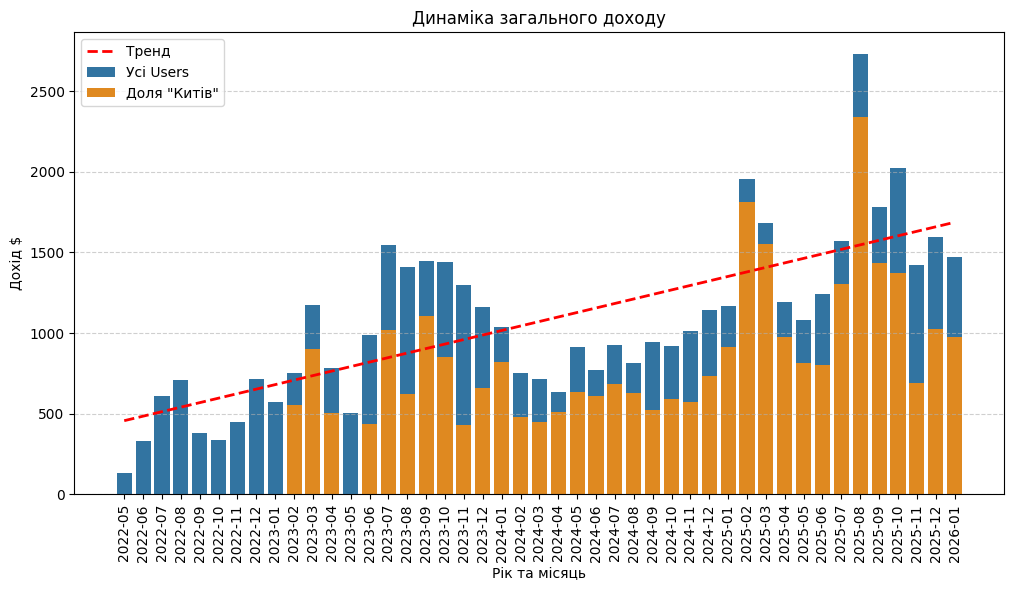

In [50]:
fig, ax = plt.subplots(figsize=(12, 6))

#trend line
trend_data = df.groupby('year_month')['total_revenue'].sum().reset_index()
x_coords = np.arange(len(trend_data))
y_coords = trend_data['total_revenue'].values
m, b = np.polyfit(x_coords, y_coords, 1)

#barchart
sns.barplot(df, 
            x='year_month',
            y='total_revenue',
            estimator=sum,
            errorbar=None,
            ax=ax)

#barchart whales only

sns.barplot(df_whales, 
            x='year_month',
            y='total_revenue',
            estimator=sum,
            errorbar=None,
            color='darkorange',
            ax=ax)

ax.plot(x_coords, m * x_coords + b, color='red', linestyle='--', linewidth=2, label='Тренд')

plt.title("Динаміка загального доходу")
plt.ylabel('Дохід $')
plt.xlabel('Рік та місяць')

plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.legend(['Тренд', 'Усі Users', 'Доля "Китів"'])



revenue_dynamic = fig

# Revenue by users 

In [51]:
df[["revenue_free", "revenue_paid", "total_revenue"]].agg(['sum', 'min', 'max', 'mean', 'median', 'std']).T

,sum,min,max,mean,median,std
revenue_free,1021.02,0.00,1.18,0.01,0.00,0.03
revenue_paid,47167.42,0.00,29.34,0.24,0.12,0.35
total_revenue,48188.44,0.06,29.34,0.25,0.12,0.35


In [52]:
ttl_revenue = sum(df['total_revenue'])

In [53]:
user_rvn = df.groupby('user_key')["total_revenue"]\
    .agg(revenue = 'sum')\
    .sort_values('revenue', ascending=False)\
    .reset_index()

In [54]:
user_rvn['%_of_total'] = user_rvn['revenue'] / ttl_revenue * 100

In [55]:
user_rvn['cumul_%'] = user_rvn['%_of_total'].cumsum()

In [56]:
whales = user_rvn[["user_key", 'revenue', '%_of_total']].head(5)

In [57]:
user_rvn = user_rvn.merge(df[['user_key', 'user_status']].drop_duplicates(), on='user_key', how='left')

**~63% доходу cгенерували лише 4 users**  
Тож подалі потрібно буде розділяти аналіз на **Усі users** та **users без "китів"**

In [58]:
user_rvn.head(15)

,user_key,revenue,%_of_total,cumul_%,user_status
0,11,11906.29,24.71,24.71,paid
1,41,8040.36,16.69,41.39,free+paid
2,3,5430.71,11.27,52.66,paid
3,597,4906.74,10.18,62.85,paid
4,445,1429.19,2.97,65.81,paid
5,1086,684.20,1.42,67.23,paid
6,137,638.57,1.33,68.56,paid
7,2358,580.65,1.20,69.76,paid
8,803,539.31,1.12,70.88,paid
9,3487,413.89,0.86,71.74,paid


**Парето графік**

In [59]:
user_rvn['cum_rvn'] = user_rvn['revenue'].cumsum()

In [60]:
user_rvn['rank'] = (user_rvn.index + 1).astype(str)

In [61]:
user_rvn.head(4)

,user_key,revenue,%_of_total,cumul_%,user_status,cum_rvn,rank
0,11,11906.29,24.71,24.71,paid,11906.29,1
1,41,8040.36,16.69,41.39,free+paid,19946.65,2
2,3,5430.71,11.27,52.66,paid,25377.36,3
3,597,4906.74,10.18,62.85,paid,30284.10,4


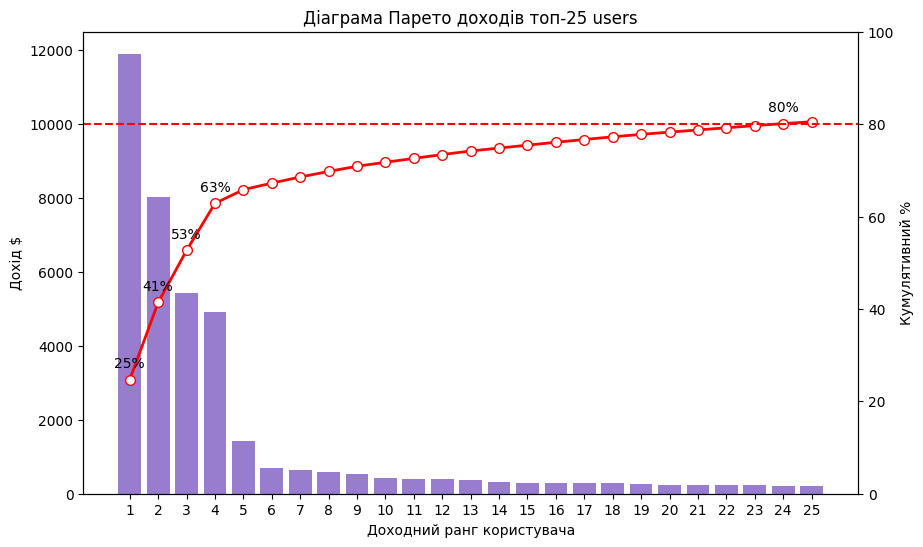

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))

#revenue user
sns.barplot(user_rvn,
            x=user_rvn['rank'].head(25),
            y='revenue',
            color='mediumpurple',
            ax=ax)

# cumul %
ax2 = ax.twinx()

sns.lineplot(user_rvn,
             x=user_rvn['rank'].head(25),
             y='cumul_%',
             
             linewidth = 2,
             color = 'red',
             marker = 'o',
             mfc = 'white',
             mec = 'red',
             mew = 1,
             ms = 7,
        
             ax=ax2)

ax2.axhline(80, linestyle='--', color='red')
ax2.set_ylim(0, 100)

for i, (x, y) in enumerate(zip(user_rvn['rank'], user_rvn['cumul_%'])):
    if i < 4 or i == 23:
        ax2.text(x, y + 2 , f'{y:.0f}%', ha='center', va='bottom')


ax.set_title("Діаграма Парето доходів топ-25 users")
ax.set_xlabel("Доходний ранг користувача")
ax.set_ylabel("Дохід $")
ax2.set_ylabel("Кумулятивний %")

pareto_users_plot = fig

**на діаграмі више бачимо що 4 користувача сгенерувало 63 % доходу, та 24 користувача сгенерувало 80% доходу.**

In [63]:
paid_users = user_rvn[user_rvn['user_status'] != 'free']

In [64]:
paid_users.describe()

,user_key,revenue,%_of_total,cumul_%,cum_rvn
count,875.00,875.00,875.00,875.00,875.00
mean,1842.91,53.95,0.11,96.18,46345.88
std,1086.53,548.54,1.14,5.98,2879.45
min,3.00,0.06,0.00,24.71,11906.29
25%,885.00,0.35,0.00,96.11,46316.29
50%,1722.00,1.41,0.00,97.53,46997.66
75%,2818.50,6.35,0.01,99.23,47818.99
max,3841.00,11906.29,24.71,100.00,48188.20


In [65]:
# 50% paid users сделали меньше $1.41 дохода,
# 80% paid users сделали меньше $10 дохода
# ~4% paid users сделали больше $100 дохода
paid_users['revenue'].quantile([0.01, 0.05, 0.1, 0.25, 0.50, 0.75, 0.80, 0.90, 0.96, 0.99])

0.01     0.06
0.05     0.12
0.10     0.12
0.25     0.35
0.50     1.41
0.75     6.35
0.80    10.02
0.90    39.73
0.96   110.94
0.99   446.50
Name: revenue, dtype: float64

In [66]:
def bin_revenue(rvn: float) -> str:
    if rvn <= 0.12:
        return '0.12'
    elif rvn <= 1:
        return '0.12-1'
    elif rvn <= 5:
        return '1-5'
    elif rvn <= 20:
        return '5-20'
    elif rvn <= 100:
        return '20-100'
    elif rvn <= 250:
        return '100-250'
    elif rvn <= 500:
        return '250-500'
    elif rvn > 500:
        return '500+'

In [67]:
order = ['0.12', '0.12-1', '1-5', '5-20', '20-100', '100-250', '250-500', '500+']

In [68]:
user_rvn['group_revenue'] = user_rvn['revenue'].apply(bin_revenue)

In [69]:
# усі users
rvn_total = user_rvn['group_revenue'].value_counts().reset_index().sort_values('group_revenue')

In [70]:
rvn_total['%_of_total'] = rvn_total['count'] / rvn_total['count'].sum() * 100

In [71]:
rvn_total['count'].sum()

np.int64(3843)

In [72]:
rvn_total

,group_revenue,count,%_of_total
1,0.12,1301,33.85
0,0.12-1,1924,50.07
2,1-5,376,9.78
5,100-250,20,0.52
4,20-100,90,2.34
6,250-500,10,0.26
3,5-20,113,2.94
7,500+,9,0.23


In [73]:
user_rvn

,user_key,revenue,%_of_total,cumul_%,user_status,cum_rvn,rank,group_revenue
0,11,11906.29,24.71,24.71,paid,11906.29,1,500+
1,41,8040.36,16.69,41.39,free+paid,19946.65,2,500+
2,3,5430.71,11.27,52.66,paid,25377.36,3,500+
3,597,4906.74,10.18,62.85,paid,30284.10,4,500+
4,445,1429.19,2.97,65.81,paid,31713.30,5,500+
...,...,...,...,...,...,...,...,...
3838,2850,0.06,0.00,100.00,paid,48188.20,3839,0.12
3839,3716,0.06,0.00,100.00,free,48188.26,3840,0.12
3840,3717,0.06,0.00,100.00,free,48188.32,3841,0.12
3841,3720,0.06,0.00,100.00,free,48188.38,3842,0.12


In [74]:
#тільки paid users
rvn_paid = user_rvn[user_rvn['user_status'] != 'free']['group_revenue']\
    .value_counts().reset_index()

In [75]:
rvn_paid['%_of_total'] = rvn_paid['count'] / rvn_paid['count'].sum() * 100

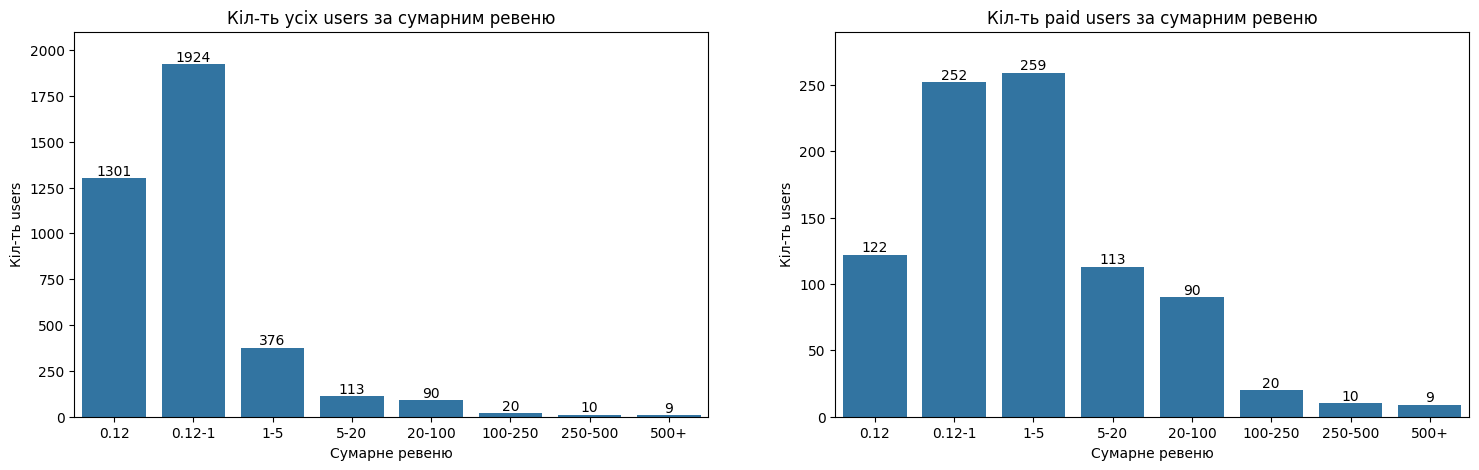

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

#total users
sns.barplot(rvn_total, 
            x='group_revenue', 
            y='count', 
            order=order,
            ax=axes[0])
axes[0].set_title("Кіл-ть усіх users за сумарним ревеню")
axes[0].set_xlabel("Сумарне ревеню")
axes[0].set_ylabel("Кіл-ть users")
axes[0].bar_label(axes[0].containers[0])
axes[0].set_ylim(0, 2100)              

#paid users
sns.barplot(rvn_paid, 
            x='group_revenue', 
            y='count', 
            order=order,
            ax=axes[1,
            ])
axes[1].set_title("Кіл-ть paid users за сумарним ревеню")
axes[1].set_xlabel("Сумарне ревеню")
axes[1].set_ylabel("Кіл-ть users")
axes[1].bar_label(axes[1].containers[0])
axes[1].set_ylim(0, 290) 

bin_revenue_plt = fig

In [77]:
rvn_paid

,group_revenue,count,%_of_total
0,1-5,259,29.60
1,0.12-1,252,28.80
2,0.12,122,13.94
3,5-20,113,12.91
4,20-100,90,10.29
5,100-250,20,2.29
6,250-500,10,1.14
7,500+,9,1.03


# по місяцах

In [78]:
df.head(1)

,id,time_utc,year_month,day_of_month,day_of_week,part_of_day,operator_key,profile_key,user_key,app_key,purchase_for,chat_or_media,user_status,credit_gross,revenue_free,revenue_paid,total_revenue,cost_per_credit
0,1,2022-05-19 01:53:00,2022-05,19,Thursday,night,2,28,3733,3,Chat per message,chat,paid,1.00,0.00,0.06,0.06,0.06


In [79]:
#місячні усі users

In [80]:
monthly = df.groupby('year_month', as_index=False)['total_revenue'].sum()

In [81]:
monthly['month_abbr'] = pd.to_datetime(monthly['year_month']).dt.month_name().str[:3]

In [82]:
by_month = monthly.groupby('month_abbr')['total_revenue'] \
    .agg(['sum', 'mean', 'median', 'std', 'min', 'max']) \
    .reset_index()

In [83]:
#місячні тільки КИТИ

In [84]:
monthly_whales = df_whales.groupby('year_month', as_index=False)['total_revenue'].sum()

In [85]:
monthly_whales['month_abbr'] = pd.to_datetime(monthly_whales['year_month']).dt.month_name().str[:3]

In [86]:
by_month_whales = monthly_whales.groupby('month_abbr')['total_revenue'] \
                                .agg(['sum', 'mean', 'median', 'std', 'min', 'max']) \
                                .reset_index()

In [87]:
#додавання % впливу китів

In [88]:
by_month_whales = by_month_whales.merge(by_month[['month_abbr', 'mean']].rename(columns={'mean':'full_mean'}),
                                  on='month_abbr',
                                  how='left')

In [89]:
by_month_whales['whale_share'] = by_month_whales['mean'] / by_month_whales['full_mean'] * 100

In [90]:
by_month_whales

,month_abbr,sum,mean,median,std,min,max,full_mean,whale_share
0,Apr,1985.26,661.75,507.33,273.20,500.74,977.20,869.97,76.07
1,Aug,3587.45,896.86,622.99,1006.86,0.00,2341.47,1413.83,63.43
2,Dec,2411.21,602.80,694.02,431.83,0.00,1023.18,1153.26,52.27
3,Feb,2843.91,947.97,553.00,748.07,480.16,1810.75,1151.05,82.36
4,Jan,2700.98,675.24,864.39,454.55,0.00,972.20,1060.36,63.68
5,Jul,3004.39,751.10,850.78,560.65,0.00,1302.83,1162.64,64.60
6,Jun,1847.79,461.95,523.79,341.74,0.00,800.21,831.96,55.53
7,Mar,2897.55,965.85,898.46,556.79,445.82,1553.26,1190.25,81.15
8,May,1451.36,362.84,317.99,425.32,0.00,815.38,654.74,55.42
9,Nov,1690.26,422.57,499.98,301.13,0.00,690.31,1045.49,40.42


In [91]:
#відновлювання порядку місяців
month_order = {m:i for i, m in enumerate(('Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'))}
by_month = by_month.sort_values('month_abbr', key=lambda x: x.map(month_order))
by_month_whales = by_month_whales.sort_values('month_abbr', key=lambda x: x.map(month_order))

In [92]:
by_month

,month_abbr,sum,mean,median,std,min,max
4,Jan,4241.42,1060.36,1101.47,374.68,568.60,1469.88
3,Feb,3453.16,1151.05,750.48,695.20,748.88,1953.81
7,Mar,3570.75,1190.25,1174.71,483.73,714.48,1681.56
0,Apr,2609.90,869.97,783.10,290.28,633.04,1193.76
8,May,2618.95,654.74,706.31,426.43,128.13,1078.22
6,Jun,3327.84,831.96,878.30,387.72,328.22,1243.03
5,Jul,4650.55,1162.64,1237.12,476.17,605.93,1570.37
1,Aug,5655.33,1413.83,1109.85,930.16,705.78,2729.85
11,Sep,4547.12,1136.78,1196.32,611.88,376.20,1778.29
10,Oct,4718.41,1179.60,1179.32,720.03,338.04,2021.72


In [93]:
by_month_whales

,month_abbr,sum,mean,median,std,min,max,full_mean,whale_share
4,Jan,2700.98,675.24,864.39,454.55,0.00,972.20,1060.36,63.68
3,Feb,2843.91,947.97,553.00,748.07,480.16,1810.75,1151.05,82.36
7,Mar,2897.55,965.85,898.46,556.79,445.82,1553.26,1190.25,81.15
0,Apr,1985.26,661.75,507.33,273.20,500.74,977.20,869.97,76.07
8,May,1451.36,362.84,317.99,425.32,0.00,815.38,654.74,55.42
6,Jun,1847.79,461.95,523.79,341.74,0.00,800.21,831.96,55.53
5,Jul,3004.39,751.10,850.78,560.65,0.00,1302.83,1162.64,64.60
1,Aug,3587.45,896.86,622.99,1006.86,0.00,2341.47,1413.83,63.43
11,Sep,3054.84,763.71,811.44,633.27,0.00,1431.96,1136.78,67.18
10,Oct,2809.11,702.28,719.18,570.08,0.00,1370.75,1179.60,59.54


In [94]:
# топ 3 місяця за середнім доходом це Август= $1414, Березень = $1190, Жовтень = $1180.
by_month.sort_values('mean', ascending=False).head(3)

,month_abbr,sum,mean,median,std,min,max
1,Aug,5655.33,1413.83,1109.85,930.16,705.78,2729.85
7,Mar,3570.75,1190.25,1174.71,483.73,714.48,1681.56
10,Oct,4718.41,1179.60,1179.32,720.03,338.04,2021.72


In [95]:
# боттом 3 місяця за середнім доходом це Травень = $655, Червень = $832, Квітень = $870.
by_month.sort_values('mean').head(3)

,month_abbr,sum,mean,median,std,min,max
8,May,2618.95,654.74,706.31,426.43,128.13,1078.22
6,Jun,3327.84,831.96,878.30,387.72,328.22,1243.03
0,Apr,2609.90,869.97,783.10,290.28,633.04,1193.76


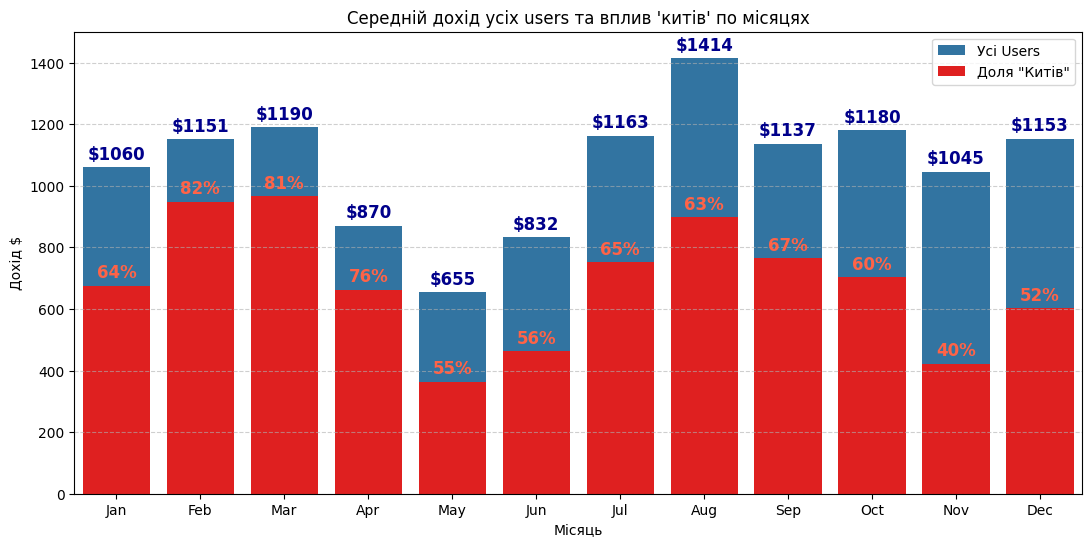

In [162]:
fig, ax = plt.subplots(figsize=(13, 6))

sns.barplot(by_month,
            x='month_abbr',
            y='mean',
            errorbar=None,
            ax=ax,
            legend=True)


sns.barplot(by_month_whales,
            x='month_abbr',
            y='mean',
            color='red',
            errorbar=None,
            ax=ax,
            legend=True)

ax.bar_label(ax.containers[0], fmt="$%.0f", color='darkblue', fontsize=12, padding=3, fontweight='bold')
ax.bar_label(ax.containers[1], fmt="$%.0f", color='tomato', fontsize=12, padding=3, fontweight='bold',
             labels=[f"{share:.0f}%" for share in by_month_whales['whale_share']])


ax.set_title("Середній дохід усіх users та вплив 'китів' по місяцях")
ax.set_ylabel("Дохід $")
ax.set_xlabel("Місяць")
ax.set_ylim(0, 1500)
plt.grid(axis='y', linestyle='--', alpha=0.6)

ax.legend(['Усі Users', 'Доля "Китів"'])

by_month_plot = fig

In [97]:
#добавленя пори року
month_season = {
    1: 'зима',
    2: 'зима',
    3: 'весна',
    4: 'весна',
    5: 'весна',
    6: 'літо',
    7: 'літо',
    8: 'літо',
    9: 'осінь',
    10: 'осінь',
    11: 'осінь',
    12: 'зима'
}
monthly['season'] = monthly['year_month'].apply(lambda x: month_season[int(x[-2:])])

In [98]:
by_season = monthly.groupby('season')['total_revenue'] \
    .agg(['sum', 'mean', 'median', 'std', 'min', 'max']) \
    .reset_index()

In [99]:
by_season

,season,sum,mean,median,std,min,max
0,весна,8799.60,879.96,846.90,431.29,128.13,1681.56
1,зима,12307.62,1118.87,1142.25,424.32,568.60,1953.81
2,літо,13633.72,1136.14,957.12,633.04,328.22,2729.85
3,осінь,13447.50,1120.63,1156.68,546.32,338.04,2021.72


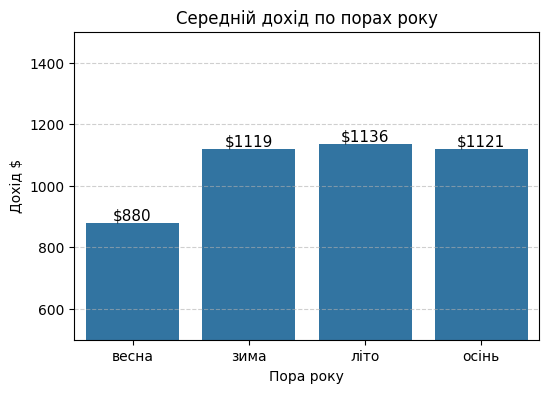

In [100]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(by_season,
            x='season',
            y='mean',
            errorbar=None,
            ax=ax,
            legend=True)

plt.grid(axis='y', linestyle='--', alpha=0.6)

ax.bar_label(ax.containers[0], fmt="$%.0f", fontsize=11)
ax.set_title("Середній дохід по порах року")
ax.set_ylabel("Дохід $")
ax.set_xlabel("Пора року")
ax.set_ylim(500, 1500)


by_month_plot = fig

### по дням

In [101]:
df.head(1)

,id,time_utc,year_month,day_of_month,day_of_week,part_of_day,operator_key,profile_key,user_key,app_key,purchase_for,chat_or_media,user_status,credit_gross,revenue_free,revenue_paid,total_revenue,cost_per_credit
0,1,2022-05-19 01:53:00,2022-05,19,Thursday,night,2,28,3733,3,Chat per message,chat,paid,1.00,0.00,0.06,0.06,0.06


In [102]:
# денне по усіх users

In [103]:
daily = df.groupby(df["time_utc"].dt.to_period("D"), as_index=False)["total_revenue"].sum()

In [104]:
daily['num_day'] = daily['time_utc'].dt.day

In [105]:
by_num_day = daily.groupby('num_day')["total_revenue"]\
                .agg(['sum', 'mean', 'median', 'std', 'min', 'max']) \
                .reset_index().rename(columns={'time_utc':'num_day'})

In [106]:
# денне по whales users

In [107]:
daily_whales = df_whales.groupby(df_whales["time_utc"].dt.to_period("D"), as_index=False)["total_revenue"].sum()

In [108]:
daily_whales['num_day'] = daily_whales['time_utc'].dt.day

In [109]:
by_num_day_whales = daily_whales.groupby('num_day')["total_revenue"]\
                               .agg(['sum', 'mean', 'median', 'std', 'min', 'max']) \
                               .reset_index().rename(columns={'time_utc':'num_day'})

In [110]:
#додаю долю % китів

In [111]:
by_num_day_whales = by_num_day_whales.merge(by_num_day[['num_day', 'mean']].rename(columns={'mean':'full_mean'}),
                                on ='num_day',
                                how ='left')

In [112]:
by_num_day_whales["whale_share"] = by_num_day_whales['mean'] / by_num_day_whales['full_mean'] * 100

In [113]:
by_num_day

,num_day,sum,mean,median,std,min,max
0,1,1098.97,24.98,21.99,20.04,0.12,106.25
1,2,1426.66,33.18,30.05,24.56,0.41,114.25
2,3,1598.18,36.32,28.37,30.86,1.00,152.70
3,4,1661.57,37.76,28.40,40.53,0.18,249.72
4,5,1601.07,36.39,28.02,34.84,0.29,185.22
5,6,1499.28,34.07,32.05,25.61,0.12,126.07
6,7,1250.68,28.42,24.46,20.71,1.65,87.02
7,8,1449.30,32.94,29.75,24.55,2.53,132.24
8,9,1523.74,35.44,26.58,20.39,11.11,103.61
9,10,1572.15,35.73,32.99,22.12,5.23,119.89


In [114]:
#топ 3 дня за середнім доходом ~$41 это 31, 27, 28.
by_num_day.sort_values('mean', ascending=False).head(3)

,num_day,sum,mean,median,std,min,max
30,31,1135.66,42.06,39.45,19.87,12.70,102.31
26,27,1891.95,42.04,32.87,27.61,1.82,119.13
27,28,1827.68,40.62,35.57,26.31,3.88,126.07


In [115]:
#боттом 3 дня за середнім доходом от $24 до $31 это 1, 7,14
by_num_day.sort_values('mean').head(3)

,num_day,sum,mean,median,std,min,max
0,1,1098.97,24.98,21.99,20.04,0.12,106.25
6,7,1250.68,28.42,24.46,20.71,1.65,87.02
13,14,1361.93,30.95,26.61,20.73,0.53,87.32


In [116]:
range(len(daily['num_day'].unique()))

range(0, 31)

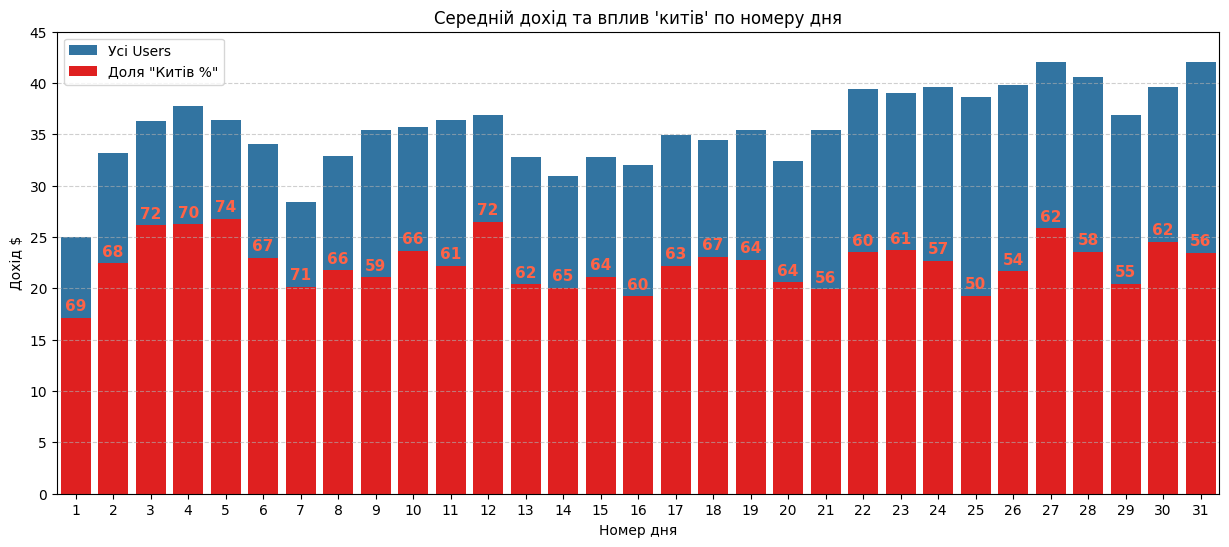

In [117]:
fig, ax = plt.subplots(figsize=(15, 6))

sns.barplot(daily,
            x='num_day',
            y='total_revenue',
            errorbar=None,
            ax=ax,)

sns.barplot(by_num_day_whales,
             x= 'num_day',
             y='mean',
             color='red',
             errorbar=None,
             ax=ax)

ax.bar_label(ax.containers[1], fmt="$%.0f", color='tomato', fontsize=11, padding=3, fontweight='bold',
             labels=[f"{share:.0f}" for share in by_num_day_whales['whale_share']])

plt.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_title("Середній дохід та вплив 'китів' по номеру дня")
plt.ylabel("Дохід $")
plt.xlabel("Номер дня")
ax.set_ylim(0, 45)

ax.legend(['Усі Users', 'Доля "Китів %"'])

avg_rvn_by_num_day = fig

In [118]:
# ревеню по началу, середине и концк месяца

In [119]:
daily['part_month'] = pd.cut(daily['num_day'],
                      bins=(0, 10, 20, 31),
                      labels=('1-10','11-20', '20-31'))

In [120]:
daily_whales['part_month'] = pd.cut(daily_whales['num_day'],
                             bins=(0, 10, 20, 31),
                             labels=('1-10','11-20', '20-31'))

In [121]:
#середнє ревеню по частинам місяця
pm_avg = daily.groupby('part_month')['total_revenue'].mean().reset_index()

In [122]:
#середнє ревеню китів по частинам місяця 
pm_avg_w = daily_whales.groupby('part_month')['total_revenue'].mean().reset_index()

In [123]:
pm_share = tuple(pm_avg_w['total_revenue'] / pm_avg['total_revenue'] * 100)

In [124]:
# на сколько процентов доход вырастает в среднем в конце месяца
(39.30 - 33.5) / 33.5 * 100

17.313432835820887

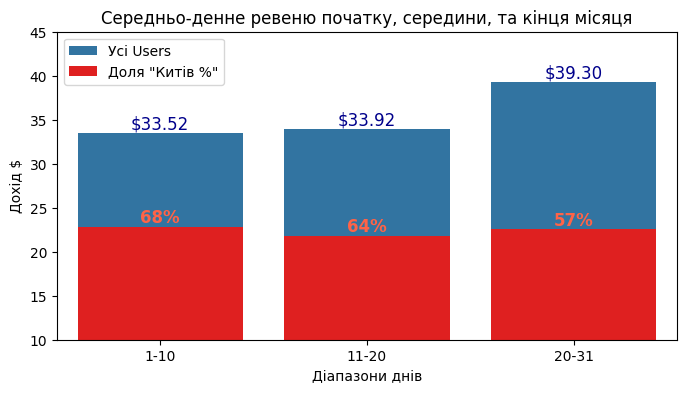

In [125]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(daily,
            x='part_month',
            y='total_revenue',
            errorbar=None,
            ax=ax,)

sns.barplot(daily_whales,
            x='part_month',
            y='total_revenue',
            color='red',
            errorbar=None,
            ax=ax,)


ax.set_title("Середньо-денне ревеню початку, середини, та кінця місяця")
plt.ylabel("Дохід $")
plt.xlabel("Діапазони днів")
ax.set_ylim(10, 45)

ax.bar_label(ax.containers[0], fmt='$%.2f', color='darkblue', fontsize=12)
ax.bar_label(ax.containers[1], fmt='$%.2f', color='tomato', fontsize=12, fontweight='bold',
            labels=[f"{el:.0f}%" for el in pm_share])

ax.legend(['Усі Users', 'Доля "Китів %"'])

avg_rvn_by_part_month = fig

### по дню недели

In [126]:
df.head(1)

,id,time_utc,year_month,day_of_month,day_of_week,part_of_day,operator_key,profile_key,user_key,app_key,purchase_for,chat_or_media,user_status,credit_gross,revenue_free,revenue_paid,total_revenue,cost_per_credit
0,1,2022-05-19 01:53:00,2022-05,19,Thursday,night,2,28,3733,3,Chat per message,chat,paid,1.00,0.00,0.06,0.06,0.06


In [127]:
days_map = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Нд'}

daily['day_ua'] = daily['time_utc'].dt.to_timestamp().dt.dayofweek.map(days_map)
daily_whales['day_ua'] = daily_whales['time_utc'].dt.to_timestamp().dt.dayofweek.map(days_map)

In [128]:
by_dow = daily.groupby('day_ua')["total_revenue"]\
                .agg(['sum', 'mean', 'median', 'std', 'min', 'max']) \
                .reset_index()

In [129]:
by_dow_whale = daily_whales.groupby('day_ua')["total_revenue"]\
                           .agg(['sum', 'mean', 'median', 'std', 'min', 'max']) \
                           .reset_index()

In [130]:
#відновленя порядку днів
days_map_2 = {d:i for i, d in days_map.items()}
by_dow = by_dow.sort_values('day_ua', key=lambda col: col.map(days_map_2))
by_dow_whale = by_dow_whale.sort_values('day_ua', key=lambda col: col.map(days_map_2))

In [131]:
by_dow

,day_ua,sum,mean,median,std,min,max
2,Пн,7265.33,37.64,31.93,28.53,0.12,249.72
0,Вт,6128.08,31.92,26.11,25.85,0.29,185.22
5,Ср,6686.91,34.65,29.28,25.92,0.12,189.51
6,Чт,6705.90,34.75,31.40,21.23,0.94,126.07
3,Пт,6831.34,35.21,29.08,23.49,0.41,143.35
4,Сб,7636.12,39.36,33.49,26.21,3.53,201.10
1,Нд,6934.75,36.12,29.87,27.88,1.06,152.70


In [132]:
by_dow_whale['full_mean'] = by_dow['mean']

In [133]:
by_dow_whale['whale_share'] = by_dow_whale['mean'] / by_dow_whale['full_mean'] * 100

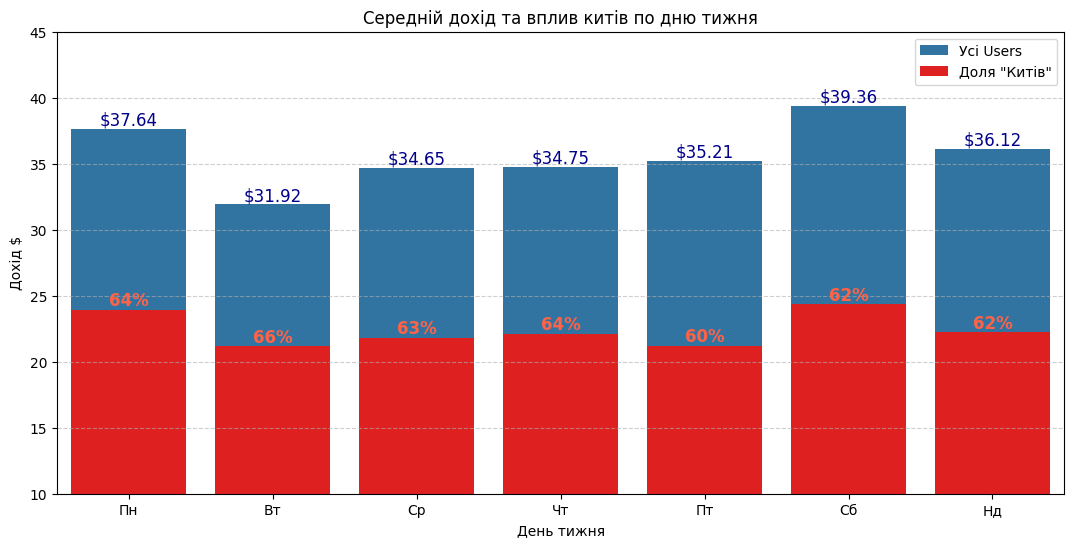

In [134]:
fig, ax = plt.subplots(figsize=(13, 6))

sns.barplot(by_dow,
            x='day_ua',
            y='mean',
            errorbar=None,
            ax=ax,)

ax.bar_label(ax.containers[0], fmt="$%.2f", color = 'darkblue', fontsize=12)

sns.barplot(by_dow_whale,
            x='day_ua',
            y='mean',
            color='red',
            errorbar=None,
            ax=ax,)

ax.bar_label(ax.containers[1], fmt='$%.2f', color='tomato', fontsize=12, fontweight='bold',
            labels=[f"{el:.0f}%" for el in by_dow_whale['whale_share']])

plt.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_title("Середній дохід та вплив китів по дню тижня")
plt.ylabel("Дохід $")
plt.xlabel("День тижня")
ax.set_ylim(10, 45)

ax.legend(['Усі Users', 'Доля "Китів"'])

avg_rvn_by_dow = fig

In [135]:
#по части дня

In [136]:
df.head(1)

,id,time_utc,year_month,day_of_month,day_of_week,part_of_day,operator_key,profile_key,user_key,app_key,purchase_for,chat_or_media,user_status,credit_gross,revenue_free,revenue_paid,total_revenue,cost_per_credit
0,1,2022-05-19 01:53:00,2022-05,19,Thursday,night,2,28,3733,3,Chat per message,chat,paid,1.00,0.00,0.06,0.06,0.06


In [137]:
df['date'] = df['time_utc'].dt.date

In [138]:
df['trunc_hour'] = df['time_utc'].dt.floor('h')

In [181]:
df_whales['trunc_hour'] = df_whales['time_utc'].dt.floor('h')

In [182]:
day_part = df.groupby(['date', 'part_of_day'])['total_revenue'].sum().reset_index()

In [183]:
by_day_part = day_part.groupby('part_of_day')["total_revenue"]\
                .agg(['sum', 'mean', 'median', 'std', 'min', 'max']) \
                .reset_index()

In [184]:
d = {'morning': 0, 
     'afternoon': 1,
     'evening': 2,
     'night': 3}

In [187]:
by_day_part = by_day_part.sort_values('part_of_day', key=lambda x: x.map(d))

In [188]:
by_day_part

,part_of_day,sum,mean,median,std,min,max
2,morning,8056.73,6.73,2.82,10.00,0.06,97.26
0,afternoon,4137.81,3.69,1.29,6.01,0.06,50.57
1,evening,10801.21,8.86,4.47,11.30,0.06,85.67
3,night,25192.69,19.13,16.58,15.55,0.06,138.36


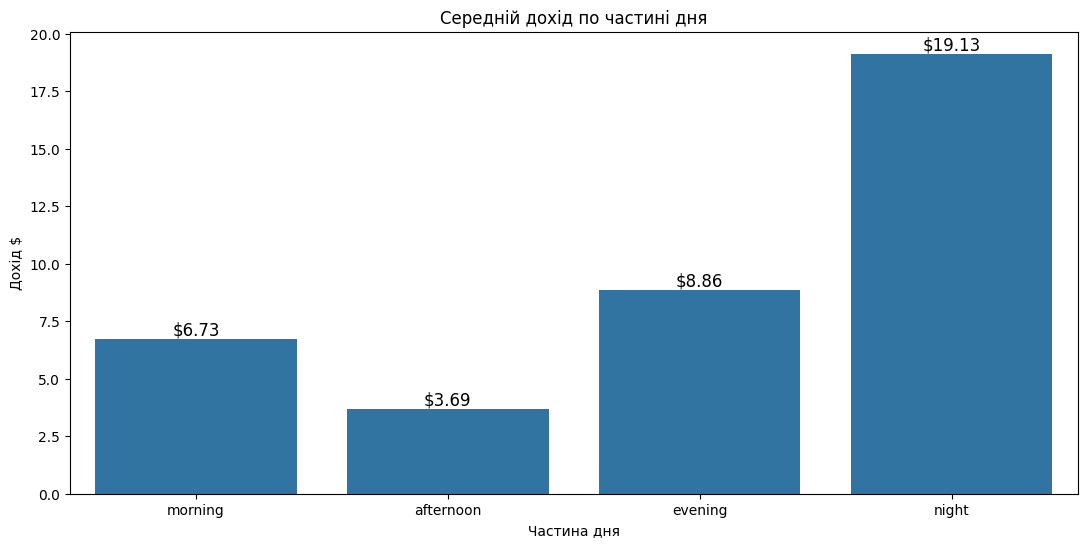

In [189]:
fig, ax = plt.subplots(figsize=(13, 6))

sns.barplot(by_day_part,
            x='part_of_day',
            y='mean',
            errorbar=None,
            ax=ax,)

ax.set_title("Середній дохід по частині дня")
plt.ylabel("Дохід $")
plt.xlabel("Частина дня")

plt.bar_label(ax.containers[0], fmt="$%0.2f", fontsize=12)

avg_rvn_by_pod = fig

In [144]:
day_hour = df.groupby(['trunc_hour'])['total_revenue'].sum().reset_index()

In [145]:
day_hour_whale = df_whales.groupby(['trunc_hour'])['total_revenue'].sum().reset_index()

In [146]:
day_hour_whale['hour'] = day_hour_whale['trunc_hour'].dt.hour

In [147]:
day_hour['hour'] = day_hour['trunc_hour'].dt.hour

In [148]:
by_hour = day_hour.groupby('hour')["total_revenue"]\
                 .agg(['sum', 'mean', 'median', 'std', 'min', 'max']) \
                 .reset_index()

In [149]:
by_hour_whale = day_hour_whale.groupby('hour')["total_revenue"]\
                .agg(['sum', 'mean', 'median', 'std', 'min', 'max']) \
                .reset_index()

In [150]:
by_hour_whale = by_hour_whale.merge(by_hour[['hour', 'mean']].rename(columns={'mean':'full_mean'}),
                    on='hour',
                    how='left')

In [151]:
by_hour_whale['whale_share'] = by_hour_whale['mean'] / by_hour_whale['full_mean'] * 100

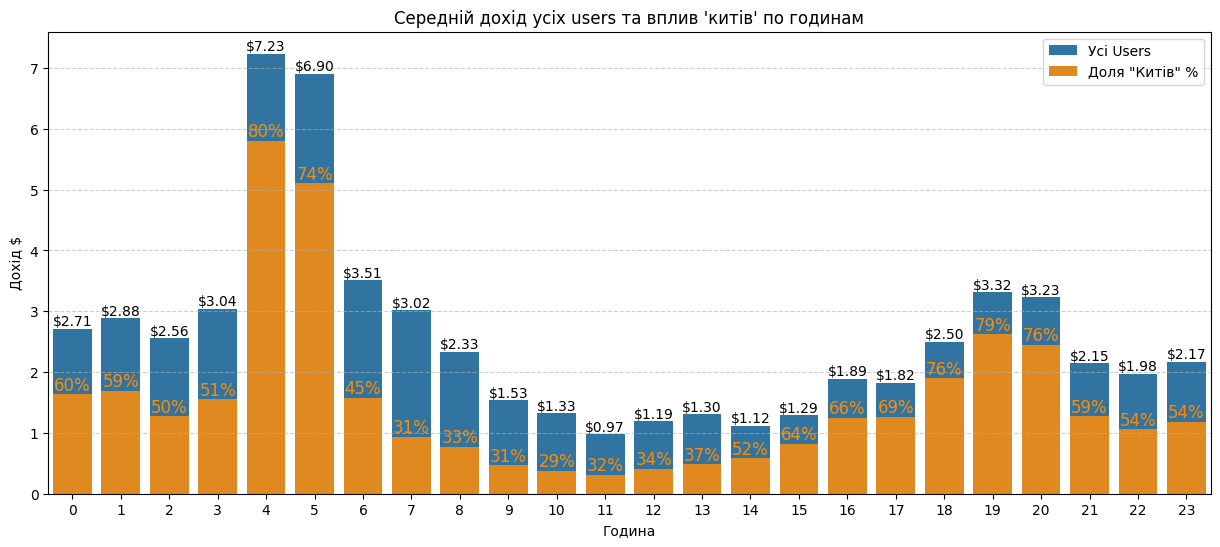

In [152]:
fig, ax = plt.subplots(figsize=(15, 6))

sns.barplot(by_hour,
            x='hour',
            y='mean',
            errorbar=None,
            ax=ax,)


sns.barplot(by_hour_whale,
            x='hour',
            y='mean',
            color = 'darkorange',
            errorbar=None,
            ax=ax)

plt.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_title("Середній дохід усіх users та вплив 'китів' по годинам")
plt.ylabel("Дохід $")
plt.xlabel("Година")

plt.bar_label(ax.containers[0], fmt="$%0.2f")
ax.bar_label(ax.containers[1], color='darkorange', fontsize=12,
            labels=[f"{el:.0f}%" for el in by_hour_whale['whale_share']])

ax.legend(['Усі Users', 'Доля "Китів" %'])

avg_rvn_by_hour = fig

In [153]:
#анализ free

# выводы

**tables**

wrong_cred_cost - рядки з аномальною вартістю credits


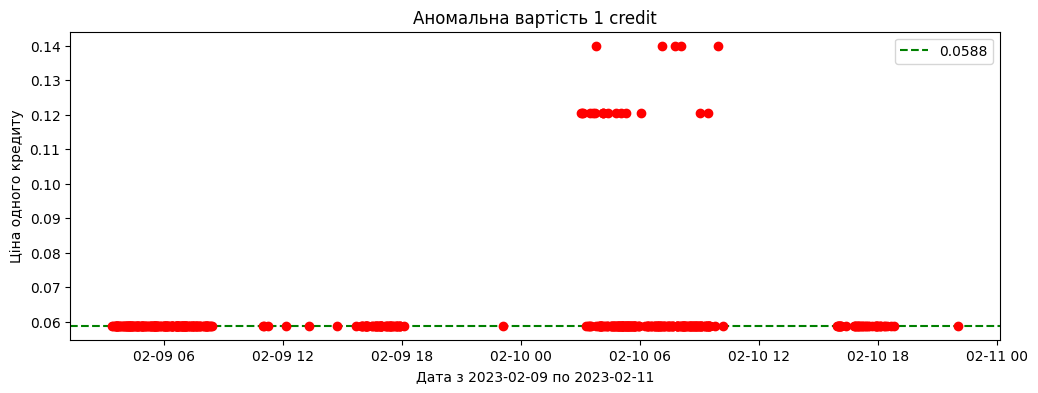

In [154]:
#аномальна вартість 1 credit
anomalies_plot

**Revenue**
<pre>
Тип                      Значення
---------------------------------
Сумарне revenue:           $48189
    Paid users:            $47167
                             ~98%
    Free users:             $1022
                              ~2%
Місячні показники:
    Середнє:             $1047.60  
    Медіана:             $1001.04  
    STD:                  $532.42
    Максимальне:         $2729.85
    
Денні показники:
    Середнє:               $35.64  
    Медіана:               $30.25  
    STD:                   $25.74
    Максимальне:          $249.72

Транзакційні показники:
    Середнє:                $0.25  
    Медіана:                $0.12  
    STD:                    $0.35
    Максимальне:           $29.34

    </pre>



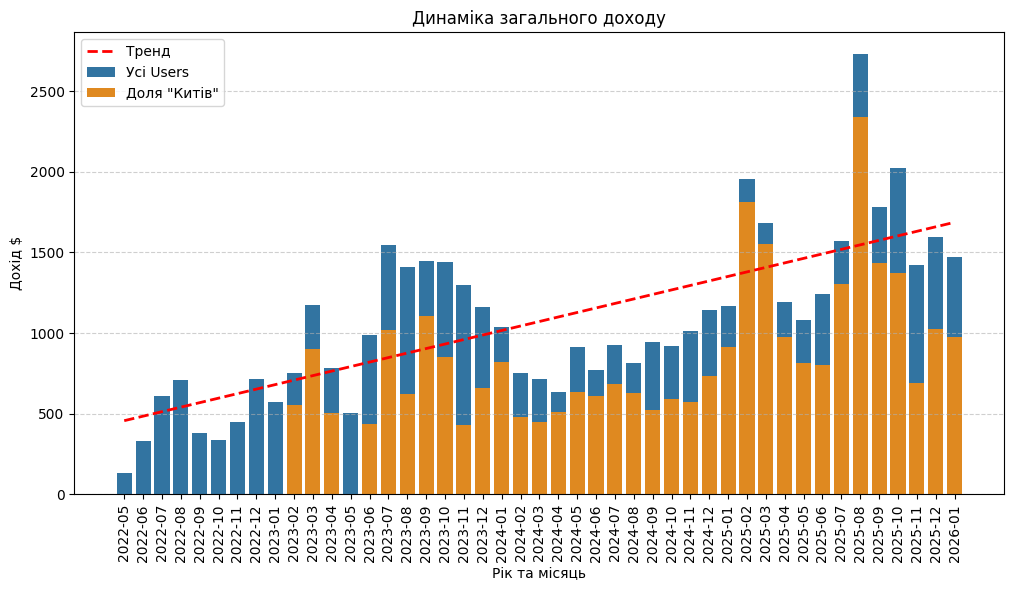

In [155]:
revenue_dynamic

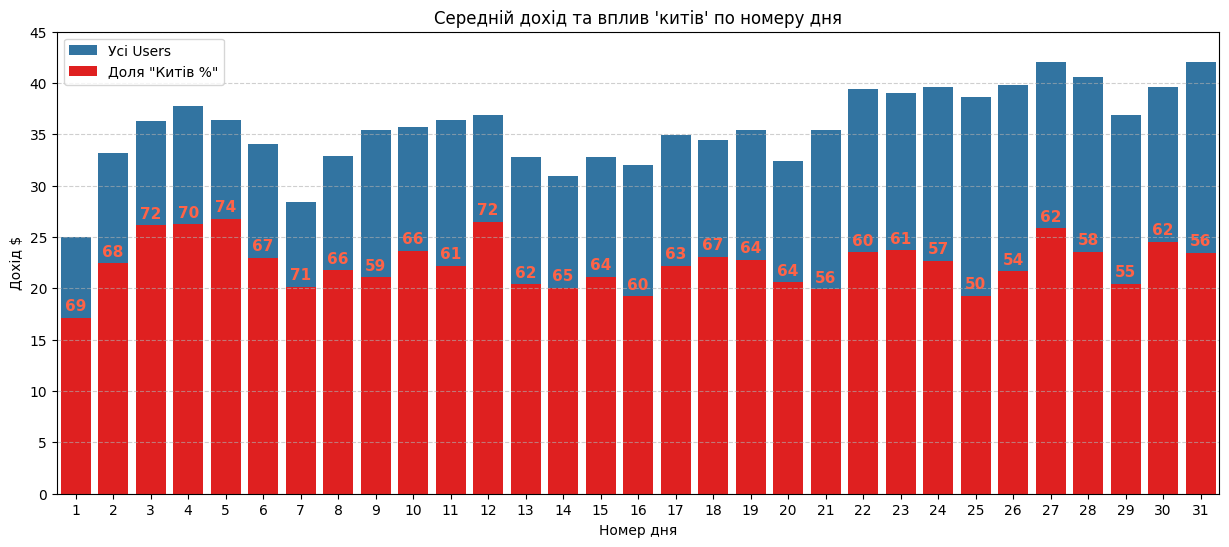

In [156]:
avg_rvn_by_num_day

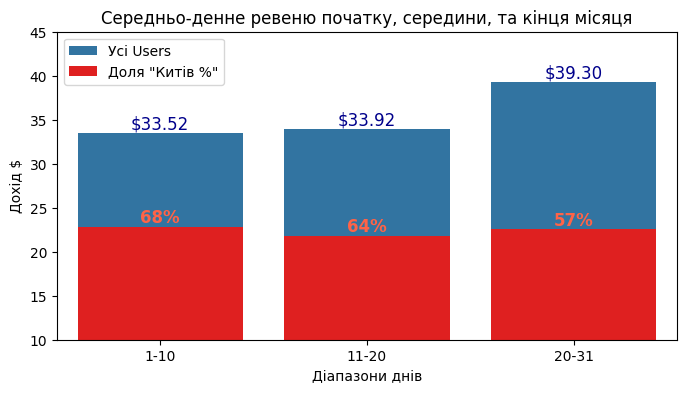

In [157]:
avg_rvn_by_part_month


**Расчитав и построив график среднего дохода в течении месяца видно как средний доход вырастает после 20 числа на 17.3% в сравнении с началом и серединой месяца.**  
<pre>
Топ за середнім доходом ~$41 это дни 31, 27, 28. 
Боттом за середнім доходом от $24 до $31 это дни 1, 7, 14.
</pre>
    

In [158]:
#киты
whales

,user_key,revenue,%_of_total
0,11,11906.29,24.71
1,41,8040.36,16.69
2,3,5430.71,11.27
3,597,4906.74,10.18
4,445,1429.19,2.97


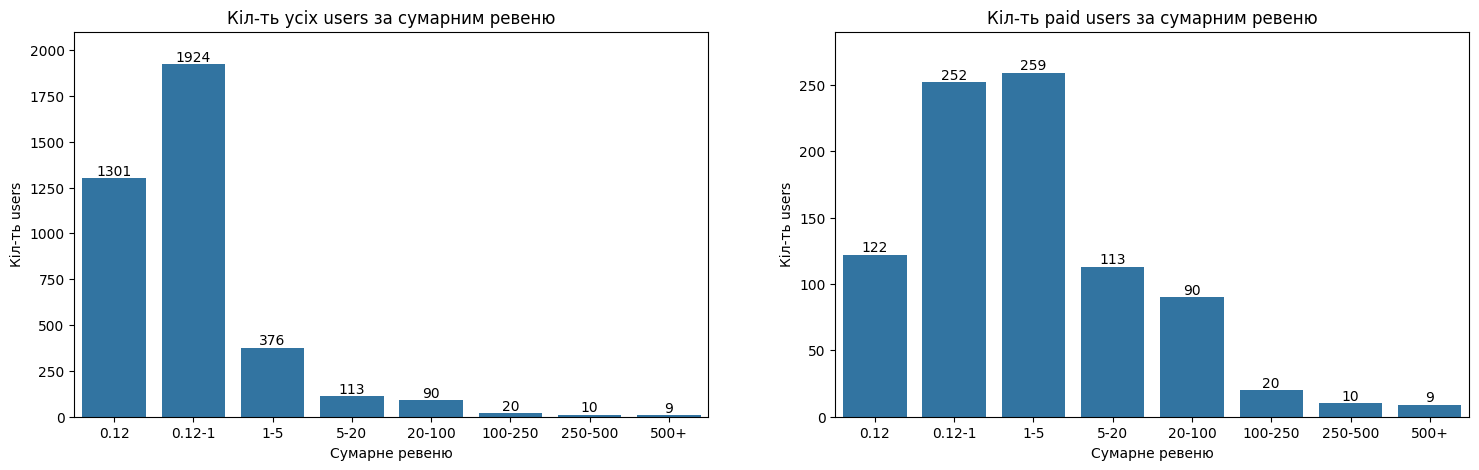

In [159]:
bin_revenue_plt

**!!! ~73% paid users сгенерировали меньше \$5 каждый.**  
**!!! ~63% доходу cгенерували лише 4 users.**  

- **50% paid users сделали меньше \$1.41 дохода**  
- **80% paid users сделали меньше \$10 дохода**  
- **~4% paid users сделали больше $100 дохода**  
